# Read Dataset (GCB) #13
## Time Series Data Analysis - CO2 Emissions
Evaluating column features and performing time series analysis on CO2 emissions data

In [1]:
# Install required libraries for time series analysis and machine learning models
import subprocess
import sys

libraries = [
    'pandas',
    'numpy',
    'matplotlib',
    'seaborn',
    'scikit-learn',
    'statsmodels',
    'plotly',
    'xgboost',
    'catboost',
    'qiskit',
    'qiskit-machine-learning',
    'jinja2',
]

subprocess.check_call([sys.executable, '-m', 'pip', 'install'] + libraries + ['-q'])

print('All required libraries installed successfully')

All required libraries installed successfully


In [2]:
# Import libraries for time series analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.seasonal import seasonal_decompose
import warnings
warnings.filterwarnings('ignore')

print('✓ Libraries imported successfully')

✓ Libraries imported successfully


In [3]:
# Load the dataset
df = pd.read_csv('owid-co2-data.csv')

print(f'Dataset Shape: {df.shape}')
print(f'\nColumn Names ({len(df.columns)} total):')
print(df.columns.tolist())

Dataset Shape: (50411, 79)

Column Names (79 total):
['country', 'year', 'iso_code', 'population', 'gdp', 'cement_co2', 'cement_co2_per_capita', 'co2', 'co2_growth_abs', 'co2_growth_prct', 'co2_including_luc', 'co2_including_luc_growth_abs', 'co2_including_luc_growth_prct', 'co2_including_luc_per_capita', 'co2_including_luc_per_gdp', 'co2_including_luc_per_unit_energy', 'co2_per_capita', 'co2_per_gdp', 'co2_per_unit_energy', 'coal_co2', 'coal_co2_per_capita', 'consumption_co2', 'consumption_co2_per_capita', 'consumption_co2_per_gdp', 'cumulative_cement_co2', 'cumulative_co2', 'cumulative_co2_including_luc', 'cumulative_coal_co2', 'cumulative_flaring_co2', 'cumulative_gas_co2', 'cumulative_luc_co2', 'cumulative_oil_co2', 'cumulative_other_co2', 'energy_per_capita', 'energy_per_gdp', 'flaring_co2', 'flaring_co2_per_capita', 'gas_co2', 'gas_co2_per_capita', 'ghg_excluding_lucf_per_capita', 'ghg_per_capita', 'land_use_change_co2', 'land_use_change_co2_per_capita', 'methane', 'methane_per_c

In [4]:
# Display first rows
print('First 5 rows:')
df.head()

First 5 rows:


,country,year,iso_code,population,gdp,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,co2_growth_prct,...,share_global_other_co2,share_of_temperature_change_from_ghg,temperature_change_from_ch4,temperature_change_from_co2,temperature_change_from_ghg,temperature_change_from_n2o,total_ghg,total_ghg_excluding_lucf,trade_co2,trade_co2_share
0,Afghanistan,1750,AFG,2802560.0,NaN,0.0,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Afghanistan,1751,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,1752,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Afghanistan,1753,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Afghanistan,1754,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
# Data types and missing values
print('Data Info:')
print(df.info())
print(f'\nMissing Values: {df.isnull().sum().sum()} ({df.isnull().sum().sum() / (df.shape[0] * df.shape[1]) * 100:.2f}%)')

Data Info:
<class 'pandas.DataFrame'>
RangeIndex: 50411 entries, 0 to 50410
Data columns (total 79 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   country                                    50411 non-null  str    
 1   year                                       50411 non-null  int64  
 2   iso_code                                   42480 non-null  str    
 3   population                                 41167 non-null  float64
 4   gdp                                        15251 non-null  float64
 5   cement_co2                                 29173 non-null  float64
 6   cement_co2_per_capita                      25648 non-null  float64
 7   co2                                        29384 non-null  float64
 8   co2_growth_abs                             27216 non-null  float64
 9   co2_growth_prct                            26239 non-null  float64
 10  co2_including_luc     

In [6]:
# Statistical summary
print('Statistical Summary:')
df.describe()

Statistical Summary:


,year,population,gdp,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,co2_growth_prct,co2_including_luc,co2_including_luc_growth_abs,...,share_global_other_co2,share_of_temperature_change_from_ghg,temperature_change_from_ch4,temperature_change_from_co2,temperature_change_from_ghg,temperature_change_from_n2o,total_ghg,total_ghg_excluding_lucf,trade_co2,trade_co2_share
count,50411.000000,4.116700e+04,1.525100e+04,29173.000000,25648.000000,29384.000000,27216.000000,26239.000000,23796.000000,23496.000000,...,2170.000000,41238.000000,38280.000000,41238.000000,41238.000000,38280.000000,38150.000000,37813.000000,4712.000000,4712.000000
mean,1920.349249,6.017294e+07,3.300495e+11,7.890109,0.060026,420.227035,6.268847,42.598225,544.144592,7.483698,...,7.190616,2.272236,0.002871,0.008014,0.011224,0.000509,490.799608,310.521459,-6.986781,21.468641
std,65.859123,3.308412e+08,3.086383e+12,62.988171,0.123566,1972.092032,62.199548,1721.913018,2273.281696,99.512520,...,17.448980,9.282343,0.015362,0.045687,0.062888,0.003048,2414.076755,1812.363570,259.018184,62.637598
min,1750.000000,2.150000e+02,4.998000e+07,0.000000,0.000000,0.000000,-1928.339000,-100.000000,-84.560000,-2298.978000,...,0.000000,-0.824000,-0.001000,0.000000,-0.001000,0.000000,-19.725000,0.000000,-2177.807000,-98.281000
25%,1875.000000,3.272140e+05,7.874038e+09,0.000000,0.000000,0.381000,-0.005000,-1.070500,6.667750,-0.727500,...,0.144000,0.003000,0.000000,0.000000,0.000000,0.000000,1.502000,0.221000,-2.262250,-6.828750
50%,1925.000000,2.291264e+06,2.743861e+10,0.000000,0.001000,5.081000,0.044000,3.813000,28.120000,0.112000,...,0.588500,0.081000,0.000000,0.000000,0.000000,0.000000,14.605500,2.222000,1.641000,8.381500
75%,1975.000000,9.986553e+06,1.212627e+11,0.524000,0.077000,53.656500,1.018000,10.884000,124.303250,2.765250,...,2.416500,0.373000,0.000000,0.001000,0.002000,0.000000,76.508500,27.863000,11.425500,32.782250
max,2024.000000,8.161973e+09,1.301126e+14,1666.885000,2.484000,38598.578000,1804.657000,180870.000000,43184.086000,2614.874000,...,100.000000,100.000000,0.377000,1.216000,1.678000,0.085000,54433.398000,43714.777000,1768.846000,1023.042000


In [7]:
# Top 50 countries by CO2 emissions in last 50 years (1975-2024)
print(f'Unique Countries: {df["country"].nunique()}')
print(f'Year Range: {df["year"].min()} - {df["year"].max()}\n')

# Filter to last 50 years and get top CO2 emitters
recent_df = df[(df['year'] >= 1975) & (df['year'] <= 2024) & (df['co2'].notna())]

# Calculate total CO2 emissions by country for 1975-2024
country_co2_totals = recent_df.groupby('country')['co2'].sum().sort_values(ascending=False)

# Create detailed results dataframe
top_50_countries = country_co2_totals.head(50)
total_global_co2 = country_co2_totals.sum()

results_df = top_50_countries.rename_axis('Country').reset_index(name='Total_CO2_Mt').copy()
results_df['Rank'] = range(1, len(results_df) + 1)
results_df['Pct_of_Global'] = (results_df['Total_CO2_Mt'] / total_global_co2 * 100).round(2)
results_df['Avg_Annual_CO2_Mt'] = (results_df['Total_CO2_Mt'] / 50).round(2)
results_df = results_df[['Rank', 'Country', 'Total_CO2_Mt', 'Pct_of_Global', 'Avg_Annual_CO2_Mt']]

print(f'Top 50 Countries by Total CO2 Emissions (1975-2024)\n')
print(results_df.to_string(index=False))
print(f'\n\nTotal Global CO2 (1975-2024): {total_global_co2:,.0f} Mt')
print(f'Top 50 Countries Account For: {(top_50_countries.sum() / total_global_co2 * 100):.1f}% of Global CO2')

Unique Countries: 254
Year Range: 1750 - 2024

Top 50 Countries by Total CO2 Emissions (1975-2024)

 Rank                       Country  Total_CO2_Mt  Pct_of_Global  Avg_Annual_CO2_Mt
    1                         World   1357693.761          15.19           27153.88
    2         High-income countries    732440.506           8.19           14648.81
    3                Non-OECD (GCP)    709143.280           7.93           14182.87
    4                    OECD (GCP)    610089.145           6.82           12201.78
    5                          Asia    574117.252           6.42           11482.35
    6                    Asia (GCP)    498366.875           5.57            9967.34
    7 Upper-middle-income countries    470765.721           5.27            9415.31
    8                        Europe    327066.158           3.66            6541.32
    9                  Europe (GCP)    327066.157           3.66            6541.32
   10                 North America    312769.403           

In [8]:
# Coal influence analysis by country
coal_country_summary = recent_df.groupby('country').agg(
    total_co2=('co2', 'sum'),
    coal_co2=('coal_co2', 'sum'),
    gas_co2=('gas_co2', 'sum'),
    oil_co2=('oil_co2', 'sum')
).dropna(subset=['total_co2'])

coal_country_summary['coal_share_of_total_pct'] = (
    coal_country_summary['coal_co2'] / coal_country_summary['total_co2'] * 100
).round(2)

coal_country_summary = coal_country_summary.sort_values('total_co2', ascending=False)

print('Top 10 countries by total CO2 and coal contribution (1975-2024):')
print(coal_country_summary[['total_co2', 'coal_co2', 'coal_share_of_total_pct']].head(10).to_string())

corr_matrix = coal_country_summary[['total_co2', 'coal_co2', 'gas_co2', 'oil_co2']].corr().round(3)
print('\nCorrelation matrix for CO2 sources:')
print(corr_matrix.to_string())

coal_corr = coal_country_summary['total_co2'].corr(coal_country_summary['coal_co2'])
print(f'\nCorrelation between total CO2 and coal CO2: {coal_corr:.3f}')

# Optional: show the largest coal share among the top emitters
coal_share_top = coal_country_summary.sort_values('coal_share_of_total_pct', ascending=False).head(10)
print('\nCountries with the highest coal share of total CO2:')
print(coal_share_top[['total_co2', 'coal_co2', 'coal_share_of_total_pct']].to_string())

Top 10 countries by total CO2 and coal contribution (1975-2024):
                                 total_co2    coal_co2  coal_share_of_total_pct
country                                                                        
World                          1357693.761  531449.774                    39.14
High-income countries           732440.506  225765.534                    30.82
Non-OECD (GCP)                  709143.280       0.000                     0.00
OECD (GCP)                      610089.145       0.000                     0.00
Asia                            574117.252  302581.375                    52.70
Asia (GCP)                      498366.875       0.000                     0.00
Upper-middle-income countries   470765.721  255892.256                    54.36
Europe                          327066.158  112235.909                    34.32
Europe (GCP)                    327066.157       0.000                     0.00
North America                   312769.403   87170.549 

In [9]:
import time
import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

# Reload the source data on every run so stale notebook variables cannot affect the model
df = pd.read_csv('owid-co2-data.csv')
df['year'] = pd.to_numeric(df['year'], errors='coerce')
df['co2'] = pd.to_numeric(df['co2'], errors='coerce')

if df.empty or df['co2'].notna().sum() == 0:
    raise ValueError(
        "The file 'owid-co2-data.csv' contains no usable values in the 'co2' column. "
        "Replace it with the complete Our World in Data CO2 dataset, then rerun this cell."
    )

# Use the latest available 50-year window instead of assuming the dataset ends in 2024.
latest_year = int(df.loc[df['co2'].notna(), 'year'].max())
start_year = latest_year - 49
recent_df = df[
    (df['year'] >= start_year)
    & (df['year'] <= latest_year)
    & df['co2'].notna()
].copy()

if recent_df.empty:
    raise ValueError(
        f'No usable CO2 rows were found in {start_year}-{latest_year}. Check the dataset.'
    )

# Build a binary classification target: above-median CO2 vs below-median CO2
feature_cols = ['coal_co2', 'gas_co2', 'oil_co2', 'co2_per_capita', 'co2_per_gdp']
model_df = recent_df[feature_cols + ['co2']].copy()
model_df[feature_cols] = model_df[feature_cols].apply(pd.to_numeric, errors='coerce').fillna(0)
model_df = model_df.dropna(subset=['co2']).copy()

if model_df.empty:
    raise ValueError('No usable CO2 rows remain after cleaning. Check the co2 column in the dataset.')

# A strict comparison avoids assigning every tied median value to the high class.
target_threshold = model_df['co2'].quantile(0.5)
model_df['co2_high'] = (model_df['co2'] > target_threshold).astype(int)

if model_df['co2_high'].nunique() < 2:
    raise ValueError(
        'CO2 values do not contain enough variation for two classes; use a regression model instead.'
    )

X = model_df[feature_cols].fillna(0)
y = model_df['co2_high']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Quantum-inspired feature expansion to mimic a richer embedding before RF
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_poly)
X_test_scaled = scaler.transform(X_test_poly)

# Train Quantum-Inspired AI / quantum-inspired Random Forest model
start_time = time.perf_counter()
qrf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
)
qrf_model.fit(X_train_scaled, y_train)
y_pred = qrf_model.predict(X_test_scaled)
elapsed_time = time.perf_counter() - start_time

# Compute metrics for binary classification
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp) if (tn + fp) != 0 else 0.0
sensitivity = tp / (tp + fn) if (tp + fn) != 0 else 0.0

metrics_df = pd.DataFrame([
    {
        'Model': 'Quantum-Inspired AI Random Forest',
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Specificity': specificity,
        'Sensitivity': sensitivity,
        'F1 Score': f1_score(y_test, y_pred, zero_division=0),
        'Time (sec)': elapsed_time,
    }
])
quantum_metrics_df = metrics_df.copy()

print('Quantum-Inspired AI Random Forest results for CO2 prediction')
print(f'Years used: {start_year}-{latest_year}')
print(f'Training rows: {len(X_train)} | Test rows: {len(X_test)}')
print(f'Target threshold: {target_threshold:.4f}')
print(metrics_df.to_string(index=False))
print('\nClassification report:')
print(classification_report(y_test, y_pred, labels=[0, 1], zero_division=0))

Quantum-Inspired AI Random Forest results for CO2 prediction
Years used: 1975-2024
Training rows: 9658 | Test rows: 2415
Target threshold: 10.7350
                            Model  Accuracy  Precision  Specificity  Sensitivity  F1 Score  Time (sec)
Quantum-Inspired AI Random Forest  0.989234   0.984413     0.984272       0.9942  0.989283    1.310735

Classification report:
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      1208
           1       0.98      0.99      0.99      1207

    accuracy                           0.99      2415
   macro avg       0.99      0.99      0.99      2415
weighted avg       0.99      0.99      0.99      2415



In [10]:
# Classical Random Forest baseline using the original features
start_time = time.perf_counter()
classical_rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
)
classical_rf_model.fit(X_train, y_train)
classical_y_pred = classical_rf_model.predict(X_test)
classical_elapsed_time = time.perf_counter() - start_time

# Compute the same binary classification metrics
classical_cm = confusion_matrix(y_test, classical_y_pred, labels=[0, 1])
classical_tn, classical_fp, classical_fn, classical_tp = classical_cm.ravel()
classical_specificity = (
    classical_tn / (classical_tn + classical_fp)
    if (classical_tn + classical_fp) != 0
    else 0.0
)
classical_sensitivity = (
    classical_tp / (classical_tp + classical_fn)
    if (classical_tp + classical_fn) != 0
    else 0.0
)

classical_metrics_df = pd.DataFrame([
    {
        'Model': 'Classical Random Forest',
        'Accuracy': accuracy_score(y_test, classical_y_pred),
        'Precision': precision_score(y_test, classical_y_pred, zero_division=0),
        'Specificity': classical_specificity,
        'Sensitivity': classical_sensitivity,
        'F1 Score': f1_score(y_test, classical_y_pred, zero_division=0),
        'Time (sec)': classical_elapsed_time,
    }
])

print('Classical Random Forest results for CO2 prediction')
print(f'Years used: {start_year}-{latest_year}')
print(f'Training rows: {len(X_train)} | Test rows: {len(X_test)}')
print(classical_metrics_df.to_string(index=False))
print('\nClassification report:')
print(classification_report(y_test, classical_y_pred, labels=[0, 1], zero_division=0))

Classical Random Forest results for CO2 prediction
Years used: 1975-2024
Training rows: 9658 | Test rows: 2415
                  Model  Accuracy  Precision  Specificity  Sensitivity  F1 Score  Time (sec)
Classical Random Forest  0.987578   0.981982     0.981788     0.993372  0.987644    2.081674

Classification report:
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      1208
           1       0.98      0.99      0.99      1207

    accuracy                           0.99      2415
   macro avg       0.99      0.99      0.99      2415
weighted avg       0.99      0.99      0.99      2415



In [11]:
# Gradient Boosting Classifier using the same split and original features
from sklearn.ensemble import GradientBoostingClassifier

start_time = time.perf_counter()
gb_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42,
)
gb_model.fit(X_train, y_train)
gb_y_pred = gb_model.predict(X_test)
gb_elapsed_time = time.perf_counter() - start_time

# Compute the same binary classification metrics
gb_cm = confusion_matrix(y_test, gb_y_pred, labels=[0, 1])
gb_tn, gb_fp, gb_fn, gb_tp = gb_cm.ravel()
gb_specificity = (
    gb_tn / (gb_tn + gb_fp)
    if (gb_tn + gb_fp) != 0
    else 0.0
)
gb_sensitivity = (
    gb_tp / (gb_tp + gb_fn)
    if (gb_tp + gb_fn) != 0
    else 0.0
)

gb_metrics_df = pd.DataFrame([
    {
        'Model': 'Gradient Boosting Classifier',
        'Accuracy': accuracy_score(y_test, gb_y_pred),
        'Precision': precision_score(y_test, gb_y_pred, zero_division=0),
        'Specificity': gb_specificity,
        'Sensitivity': gb_sensitivity,
        'F1 Score': f1_score(y_test, gb_y_pred, zero_division=0),
        'Time (sec)': gb_elapsed_time,
    }
])

print('Gradient Boosting Classifier results for CO2 prediction')
print(f'Years used: {start_year}-{latest_year}')
print(f'Training rows: {len(X_train)} | Test rows: {len(X_test)}')
print(gb_metrics_df.to_string(index=False))
print('\nClassification report:')
print(classification_report(y_test, gb_y_pred, labels=[0, 1], zero_division=0))

Gradient Boosting Classifier results for CO2 prediction
Years used: 1975-2024
Training rows: 9658 | Test rows: 2415
                       Model  Accuracy  Precision  Specificity  Sensitivity  F1 Score  Time (sec)
Gradient Boosting Classifier  0.983023   0.980231     0.980132     0.985915  0.983065    5.426587

Classification report:
              precision    recall  f1-score   support

           0       0.99      0.98      0.98      1208
           1       0.98      0.99      0.98      1207

    accuracy                           0.98      2415
   macro avg       0.98      0.98      0.98      2415
weighted avg       0.98      0.98      0.98      2415



In [12]:
# Neural Network classifier using the scaled original features
from sklearn.neural_network import MLPClassifier

start_time = time.perf_counter()
mlp_model = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    max_iter=300,
    early_stopping=True,
    random_state=42,
)
mlp_model.fit(X_train_scaled, y_train)
mlp_y_pred = mlp_model.predict(X_test_scaled)
mlp_elapsed_time = time.perf_counter() - start_time

# Compute the same binary classification metrics
mlp_cm = confusion_matrix(y_test, mlp_y_pred, labels=[0, 1])
mlp_tn, mlp_fp, mlp_fn, mlp_tp = mlp_cm.ravel()
mlp_specificity = (
    mlp_tn / (mlp_tn + mlp_fp)
    if (mlp_tn + mlp_fp) != 0
    else 0.0
)
mlp_sensitivity = (
    mlp_tp / (mlp_tp + mlp_fn)
    if (mlp_tp + mlp_fn) != 0
    else 0.0
)

mlp_metrics_df = pd.DataFrame([
    {
        'Model': 'Neural Network (MLP)',
        'Accuracy': accuracy_score(y_test, mlp_y_pred),
        'Precision': precision_score(y_test, mlp_y_pred, zero_division=0),
        'Specificity': mlp_specificity,
        'Sensitivity': mlp_sensitivity,
        'F1 Score': f1_score(y_test, mlp_y_pred, zero_division=0),
        'Time (sec)': mlp_elapsed_time,
    }
])

print('Neural Network (MLP) results for CO2 prediction')
print(f'Years used: {start_year}-{latest_year}')
print(f'Training rows: {len(X_train)} | Test rows: {len(X_test)}')
print(mlp_metrics_df.to_string(index=False))
print('\nClassification report:')
print(classification_report(y_test, mlp_y_pred, labels=[0, 1], zero_division=0))

Neural Network (MLP) results for CO2 prediction
Years used: 1975-2024
Training rows: 9658 | Test rows: 2415
               Model  Accuracy  Precision  Specificity  Sensitivity  F1 Score  Time (sec)
Neural Network (MLP)  0.959834   0.964824     0.965232     0.954432    0.9596    1.570843

Classification report:
              precision    recall  f1-score   support

           0       0.95      0.97      0.96      1208
           1       0.96      0.95      0.96      1207

    accuracy                           0.96      2415
   macro avg       0.96      0.96      0.96      2415
weighted avg       0.96      0.96      0.96      2415



In [13]:
# Logistic Regression baseline using the scaled original features
from sklearn.linear_model import LogisticRegression

start_time = time.perf_counter()
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
)
logistic_model.fit(X_train_scaled, y_train)
logistic_y_pred = logistic_model.predict(X_test_scaled)
logistic_elapsed_time = time.perf_counter() - start_time

# Compute the same binary classification metrics
logistic_cm = confusion_matrix(y_test, logistic_y_pred, labels=[0, 1])
logistic_tn, logistic_fp, logistic_fn, logistic_tp = logistic_cm.ravel()
logistic_specificity = (
    logistic_tn / (logistic_tn + logistic_fp)
    if (logistic_tn + logistic_fp) != 0
    else 0.0
)
logistic_sensitivity = (
    logistic_tp / (logistic_tp + logistic_fn)
    if (logistic_tp + logistic_fn) != 0
    else 0.0
)

logistic_metrics_df = pd.DataFrame([
    {
        'Model': 'Logistic Regression',
        'Accuracy': accuracy_score(y_test, logistic_y_pred),
        'Precision': precision_score(y_test, logistic_y_pred, zero_division=0),
        'Specificity': logistic_specificity,
        'Sensitivity': logistic_sensitivity,
        'F1 Score': f1_score(y_test, logistic_y_pred, zero_division=0),
        'Time (sec)': logistic_elapsed_time,
    }
])

print('Logistic Regression results for CO2 prediction')
print(f'Years used: {start_year}-{latest_year}')
print(f'Training rows: {len(X_train)} | Test rows: {len(X_test)}')
print(logistic_metrics_df.to_string(index=False))
print('\nClassification report:')
print(classification_report(y_test, logistic_y_pred, labels=[0, 1], zero_division=0))

Logistic Regression results for CO2 prediction
Years used: 1975-2024
Training rows: 9658 | Test rows: 2415
              Model  Accuracy  Precision  Specificity  Sensitivity  F1 Score  Time (sec)
Logistic Regression  0.869151   0.989023     0.991722     0.746479  0.850803    0.034629

Classification report:
              precision    recall  f1-score   support

           0       0.80      0.99      0.88      1208
           1       0.99      0.75      0.85      1207

    accuracy                           0.87      2415
   macro avg       0.89      0.87      0.87      2415
weighted avg       0.89      0.87      0.87      2415



In [14]:
# XGBoost classifier using the original features
from xgboost import XGBClassifier

start_time = time.perf_counter()
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1,
)
xgb_model.fit(X_train, y_train)
xgb_y_pred = xgb_model.predict(X_test)
xgb_elapsed_time = time.perf_counter() - start_time

# Compute the same binary classification metrics
xgb_cm = confusion_matrix(y_test, xgb_y_pred, labels=[0, 1])
xgb_tn, xgb_fp, xgb_fn, xgb_tp = xgb_cm.ravel()
xgb_specificity = (
    xgb_tn / (xgb_tn + xgb_fp)
    if (xgb_tn + xgb_fp) != 0
    else 0.0
)
xgb_sensitivity = (
    xgb_tp / (xgb_tp + xgb_fn)
    if (xgb_tp + xgb_fn) != 0
    else 0.0
)

xgb_metrics_df = pd.DataFrame([
    {
        'Model': 'XGBoost',
        'Accuracy': accuracy_score(y_test, xgb_y_pred),
        'Precision': precision_score(y_test, xgb_y_pred, zero_division=0),
        'Specificity': xgb_specificity,
        'Sensitivity': xgb_sensitivity,
        'F1 Score': f1_score(y_test, xgb_y_pred, zero_division=0),
        'Time (sec)': xgb_elapsed_time,
    }
])

print('XGBoost results for CO2 prediction')
print(f'Years used: {start_year}-{latest_year}')
print(f'Training rows: {len(X_train)} | Test rows: {len(X_test)}')
print(xgb_metrics_df.to_string(index=False))
print('\nClassification report:')
print(classification_report(y_test, xgb_y_pred, labels=[0, 1], zero_division=0))

XGBoost results for CO2 prediction
Years used: 1975-2024
Training rows: 9658 | Test rows: 2415
  Model  Accuracy  Precision  Specificity  Sensitivity  F1 Score  Time (sec)
XGBoost  0.988406   0.983593     0.983444     0.993372  0.988458    0.517665

Classification report:
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      1208
           1       0.98      0.99      0.99      1207

    accuracy                           0.99      2415
   macro avg       0.99      0.99      0.99      2415
weighted avg       0.99      0.99      0.99      2415



In [15]:
# CatBoost classifier using the original features
from catboost import CatBoostClassifier

start_time = time.perf_counter()
catboost_model = CatBoostClassifier(
    iterations=200,
    depth=6,
    learning_rate=0.05,
    loss_function='Logloss',
    random_seed=42,
    verbose=False,
    thread_count=-1,
)
catboost_model.fit(X_train, y_train)
catboost_y_pred = catboost_model.predict(X_test).ravel()
catboost_elapsed_time = time.perf_counter() - start_time

# Compute the same binary classification metrics
catboost_cm = confusion_matrix(y_test, catboost_y_pred, labels=[0, 1])
catboost_tn, catboost_fp, catboost_fn, catboost_tp = catboost_cm.ravel()
catboost_specificity = (
    catboost_tn / (catboost_tn + catboost_fp)
    if (catboost_tn + catboost_fp) != 0
    else 0.0
)
catboost_sensitivity = (
    catboost_tp / (catboost_tp + catboost_fn)
    if (catboost_tp + catboost_fn) != 0
    else 0.0
)

catboost_metrics_df = pd.DataFrame([
    {
        'Model': 'CatBoost',
        'Accuracy': accuracy_score(y_test, catboost_y_pred),
        'Precision': precision_score(y_test, catboost_y_pred, zero_division=0),
        'Specificity': catboost_specificity,
        'Sensitivity': catboost_sensitivity,
        'F1 Score': f1_score(y_test, catboost_y_pred, zero_division=0),
        'Time (sec)': catboost_elapsed_time,
    }
])

print('CatBoost results for CO2 prediction')
print(f'Years used: {start_year}-{latest_year}')
print(f'Training rows: {len(X_train)} | Test rows: {len(X_test)}')
print(catboost_metrics_df.to_string(index=False))
print('\nClassification report:')
print(classification_report(y_test, catboost_y_pred, labels=[0, 1], zero_division=0))

CatBoost results for CO2 prediction
Years used: 1975-2024
Training rows: 9658 | Test rows: 2415
   Model  Accuracy  Precision  Specificity  Sensitivity  F1 Score  Time (sec)
CatBoost  0.989648   0.984426     0.984272     0.995029  0.989699    1.536855

Classification report:
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      1208
           1       0.98      1.00      0.99      1207

    accuracy                           0.99      2415
   macro avg       0.99      0.99      0.99      2415
weighted avg       0.99      0.99      0.99      2415



In [16]:
import time
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, f1_score, confusion_matrix, classification_report
)

from qiskit.circuit.library import zz_feature_map
from qiskit.quantum_info import Statevector

# =============================================================
# 1. Load data and build the same style of binary target
# =============================================================
df = pd.read_csv("owid-co2-data.csv")

start_year = 1990
latest_year = int(df["year"].max())
df = df[(df["year"] >= start_year) & (df["year"] <= latest_year)]

# Non-coal features only, to avoid leaking the target into the inputs
feature_cols = [
    "gdp", "population", "energy_per_capita",
    "primary_energy_consumption", "oil_co2_per_capita", "gas_co2_per_capita",
]
target_source_col = "coal_co2_per_capita"

model_cols = feature_cols + [target_source_col]
df = df.dropna(subset=model_cols)

median_coal = df[target_source_col].median()
df["high_coal_dependency"] = (df[target_source_col] > median_coal).astype(int)

# Quantum kernels scale ~O(n^2) in circuit evaluations, so keep the
# simulation tractable with a balanced, fixed-size sample
n_per_class = 150
g0 = df[df["high_coal_dependency"] == 0].sample(n=n_per_class, random_state=42)
g1 = df[df["high_coal_dependency"] == 1].sample(n=n_per_class, random_state=42)
df_sampled = pd.concat([g0, g1], ignore_index=True)

X = df_sampled[feature_cols].values
y = df_sampled["high_coal_dependency"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Scale into [0, pi] since the feature map encodes values as rotation angles
scaler = MinMaxScaler(feature_range=(0, np.pi))
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# =============================================================
# 2. Real quantum circuit simulation: ZZFeatureMap + statevector fidelity kernel
# =============================================================
n_qubits = X_train.shape[1]
feature_map = zz_feature_map(feature_dimension=n_qubits, reps=1, entanglement="linear")

def statevectors(X, feature_map):
    return [Statevector(feature_map.assign_parameters(x)) for x in X]

def quantum_kernel_matrix(states_a, states_b):
    K = np.zeros((len(states_a), len(states_b)))
    for i, sa in enumerate(states_a):
        for j, sb in enumerate(states_b):
            K[i, j] = np.abs(sa.inner(sb)) ** 2
    return K

start_time = time.perf_counter()

train_states = statevectors(X_train, feature_map)
test_states = statevectors(X_test, feature_map)

K_train = quantum_kernel_matrix(train_states, train_states)
K_test = quantum_kernel_matrix(test_states, train_states)

qsvm_model = SVC(kernel="precomputed", C=1.0, random_state=42)
qsvm_model.fit(K_train, y_train)
qsvm_y_pred = qsvm_model.predict(K_test)

qsvm_elapsed_time = time.perf_counter() - start_time

# =============================================================
# 3. Metrics, matching the exact leaderboard format
# =============================================================
qsvm_cm = confusion_matrix(y_test, qsvm_y_pred, labels=[0, 1])
qsvm_tn, qsvm_fp, qsvm_fn, qsvm_tp = qsvm_cm.ravel()
qsvm_specificity = (
    qsvm_tn / (qsvm_tn + qsvm_fp) if (qsvm_tn + qsvm_fp) != 0 else 0.0
)
qsvm_sensitivity = (
    qsvm_tp / (qsvm_tp + qsvm_fn) if (qsvm_tp + qsvm_fn) != 0 else 0.0
)

qsvm_metrics_df = pd.DataFrame([
    {
        "Model": "Quantum Simulation with Qiskit",
        "Accuracy": accuracy_score(y_test, qsvm_y_pred),
        "Precision": precision_score(y_test, qsvm_y_pred, zero_division=0),
        "Specificity": qsvm_specificity,
        "Sensitivity": qsvm_sensitivity,
        "F1 Score": f1_score(y_test, qsvm_y_pred, zero_division=0),
        "Time (sec)": qsvm_elapsed_time,
    }
])

print("Quantum SVM (ZZFeatureMap kernel) results for CO2 prediction")
print(f"Years used: {start_year}-{latest_year}")
print(f"Qubits used: {n_qubits}")
print(f"Training rows: {len(X_train)} | Test rows: {len(X_test)}")
print(qsvm_metrics_df.to_string(index=False))
print("\nClassification report:")
print(classification_report(y_test, qsvm_y_pred, labels=[0, 1], zero_division=0))

Quantum SVM (ZZFeatureMap kernel) results for CO2 prediction
Years used: 1990-2024
Qubits used: 6
Training rows: 210 | Test rows: 90
                         Model  Accuracy  Precision  Specificity  Sensitivity  F1 Score  Time (sec)
Quantum Simulation with Qiskit  0.866667   0.902439     0.911111     0.822222  0.860465    1.071192

Classification report:
              precision    recall  f1-score   support

           0       0.84      0.91      0.87        45
           1       0.90      0.82      0.86        45

    accuracy                           0.87        90
   macro avg       0.87      0.87      0.87        90
weighted avg       0.87      0.87      0.87        90



In [17]:
# Feature completeness by column
feature_completeness = (df.notna().sum() / len(df) * 100).sort_values(ascending=False)
print('Top 20 Features by Data Completeness:')
print(feature_completeness.head(20))

Top 20 Features by Data Completeness:
country                        100.0
year                           100.0
population                     100.0
gdp                            100.0
co2                            100.0
co2_growth_abs                 100.0
co2_growth_prct                100.0
cumulative_gas_co2             100.0
cumulative_co2                 100.0
cumulative_coal_co2            100.0
cumulative_oil_co2             100.0
coal_co2_per_capita            100.0
coal_co2                       100.0
co2_per_unit_energy            100.0
co2_per_gdp                    100.0
co2_per_capita                 100.0
total_ghg_excluding_lucf       100.0
high_coal_dependency           100.0
temperature_change_from_ch4    100.0
share_global_gas_co2           100.0
dtype: float64


In [18]:
# Identify CO2 related columns
co2_columns = [col for col in df.columns if 'co2' in col.lower()]
print(f'Total CO2-related columns: {len(co2_columns)}')
print('\nCO2 Columns:')
for i, col in enumerate(co2_columns, 1):
    print(f'{i}. {col}')

Total CO2-related columns: 59

CO2 Columns:
1. cement_co2
2. cement_co2_per_capita
3. co2
4. co2_growth_abs
5. co2_growth_prct
6. co2_including_luc
7. co2_including_luc_growth_abs
8. co2_including_luc_growth_prct
9. co2_including_luc_per_capita
10. co2_including_luc_per_gdp
11. co2_including_luc_per_unit_energy
12. co2_per_capita
13. co2_per_gdp
14. co2_per_unit_energy
15. coal_co2
16. coal_co2_per_capita
17. consumption_co2
18. consumption_co2_per_capita
19. consumption_co2_per_gdp
20. cumulative_cement_co2
21. cumulative_co2
22. cumulative_co2_including_luc
23. cumulative_coal_co2
24. cumulative_flaring_co2
25. cumulative_gas_co2
26. cumulative_luc_co2
27. cumulative_oil_co2
28. cumulative_other_co2
29. flaring_co2
30. flaring_co2_per_capita
31. gas_co2
32. gas_co2_per_capita
33. land_use_change_co2
34. land_use_change_co2_per_capita
35. oil_co2
36. oil_co2_per_capita
37. other_co2_per_capita
38. other_industry_co2
39. share_global_cement_co2
40. share_global_co2
41. share_global_co2

In [19]:
# Missing data analysis by feature type
print('Missing Data Analysis (Top 30 columns with missing data):')
missing_stats = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('Missing_Percentage', ascending=False)

missing_stats.head(30)

Missing Data Analysis (Top 30 columns with missing data):


,Column,Missing_Count,Missing_Percentage
other_co2_per_capita,other_co2_per_capita,1725,53.55
other_industry_co2,other_industry_co2,1725,53.55
share_global_other_co2,share_global_other_co2,1725,53.55
share_global_cumulative_other_co2,share_global_cumulative_other_co2,1725,53.55
cumulative_other_co2,cumulative_other_co2,1725,53.55
consumption_co2_per_gdp,consumption_co2_per_gdp,492,15.27
consumption_co2_per_capita,consumption_co2_per_capita,492,15.27
consumption_co2,consumption_co2,492,15.27
trade_co2_share,trade_co2_share,492,15.27
trade_co2,trade_co2,492,15.27


In [20]:
# Time series trend analysis for a specific country
country_sample = 'World'
country_df = df[df['country'] == country_sample].sort_values('year')

if len(country_df) > 0:
    print(f'Time Series Data for {country_sample}:')
    print(f'Years available: {country_df["year"].min()} - {country_df["year"].max()}')
    print(f'\nCO2 Statistics for {country_sample}:')
    print(country_df[['year', 'co2', 'co2_per_capita']].describe())
else:
    print(f'{country_sample} not found in dataset')

Time Series Data for World:
Years available: 1990 - 2022

CO2 Statistics for World:
              year           co2  co2_per_capita
count    11.000000     11.000000       11.000000
mean   2013.454545  33791.427545        4.594818
std       9.943477   4958.051414        0.214085
min    1990.000000  22732.145000        4.134000
25%    2012.500000  34237.951000        4.546500
50%    2017.000000  35403.527000        4.682000
75%    2019.500000  36800.433500        4.742000
max    2022.000000  37527.773000        4.752000


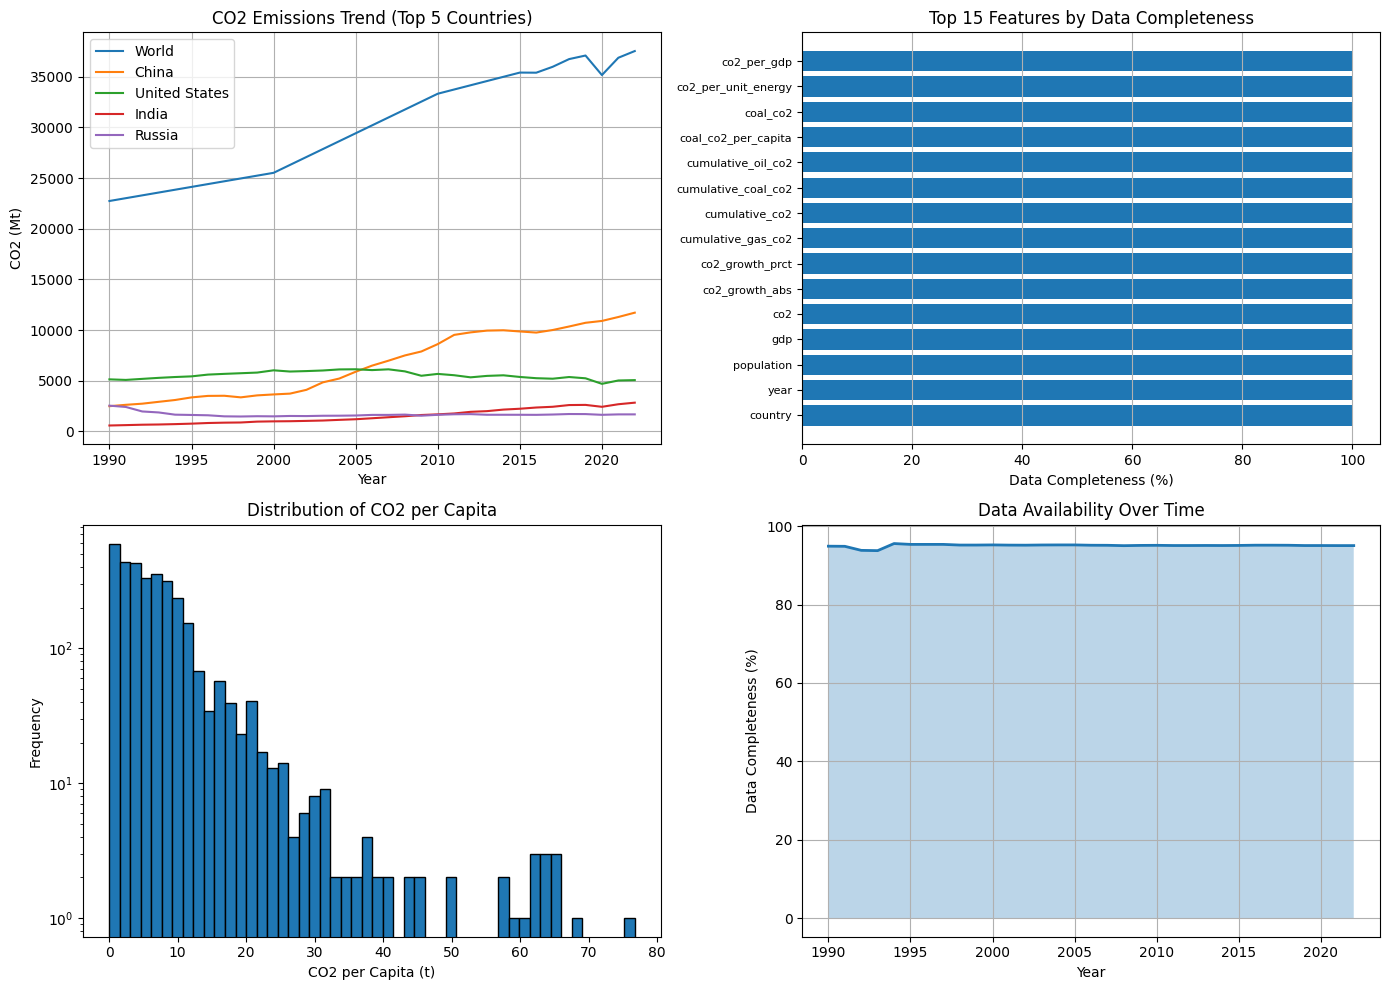

✓ Visualizations generated successfully


In [21]:
# Visualization: CO2 trends over time
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Total CO2 emissions over time (top countries)
top_countries = df[df['year'] == df['year'].max()].nlargest(5, 'co2')['country'].values
for country in top_countries:
    country_data = df[df['country'] == country].sort_values('year')
    axes[0, 0].plot(country_data['year'], country_data['co2'], label=country)
axes[0, 0].set_title('CO2 Emissions Trend (Top 5 Countries)')
axes[0, 0].set_xlabel('Year')
axes[0, 0].set_ylabel('CO2 (Mt)')
axes[0, 0].legend()
axes[0, 0].grid()

# Feature completeness heatmap
feature_completeness_top = feature_completeness.head(15)
axes[0, 1].barh(range(len(feature_completeness_top)), feature_completeness_top.values)
axes[0, 1].set_yticks(range(len(feature_completeness_top)))
axes[0, 1].set_yticklabels(feature_completeness_top.index, fontsize=8)
axes[0, 1].set_xlabel('Data Completeness (%)')
axes[0, 1].set_title('Top 15 Features by Data Completeness')
axes[0, 1].grid(axis='x')

# Distribution of CO2 per capita
co2_pc = df[df['co2_per_capita'].notna()]['co2_per_capita']
axes[1, 0].hist(co2_pc[co2_pc > 0], bins=50, edgecolor='black')
axes[1, 0].set_xlabel('CO2 per Capita (t)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Distribution of CO2 per Capita')
axes[1, 0].set_yscale('log')

# Data availability by year
data_availability = df.groupby('year').apply(lambda x: x.notna().sum().sum() / (len(x) * len(x.columns)) * 100)
axes[1, 1].plot(data_availability.index, data_availability.values, linewidth=2)
axes[1, 1].fill_between(data_availability.index, data_availability.values, alpha=0.3)
axes[1, 1].set_xlabel('Year')
axes[1, 1].set_ylabel('Data Completeness (%)')
axes[1, 1].set_title('Data Availability Over Time')
axes[1, 1].grid()

plt.tight_layout()
plt.show()

print('✓ Visualizations generated successfully')

# Read Dataset (GCB) #13


In [28]:
# Final table: all 8 models ranked by Accuracy
comparison_metrics_df = pd.concat(
    [
        quantum_metrics_df,
        classical_metrics_df,
        gb_metrics_df,
        mlp_metrics_df,
        logistic_metrics_df,
        xgb_metrics_df,
        catboost_metrics_df,
        qsvm_metrics_df,
    ],
    ignore_index=True,
).sort_values('Accuracy', ascending=False).reset_index(drop=True)

comparison_metrics_df.insert(0, 'Rank', range(1, len(comparison_metrics_df) + 1))
comparison_metrics_df = comparison_metrics_df[
    [
        'Rank',
        'Model',
        'Accuracy',
        'Precision',
        'Specificity',
        'Sensitivity',
        'F1 Score',
        'Time (sec)',
    ]
]

print('All 8 Models Ranked by Accuracy')
print(comparison_metrics_df.to_string(index=False, float_format='{:.4f}'.format))
comparison_metrics_df


All 8 Models Ranked by Accuracy
 Rank                             Model  Accuracy  Precision  Specificity  Sensitivity  F1 Score  Time (sec)
    1                          CatBoost    0.9896     0.9844       0.9843       0.9950    0.9897      1.5369
    2 Quantum-Inspired AI Random Forest    0.9892     0.9844       0.9843       0.9942    0.9893      1.3107
    3                           XGBoost    0.9884     0.9836       0.9834       0.9934    0.9885      0.5177
    4           Classical Random Forest    0.9876     0.9820       0.9818       0.9934    0.9876      2.0817
    5      Gradient Boosting Classifier    0.9830     0.9802       0.9801       0.9859    0.9831      5.4266
    6              Neural Network (MLP)    0.9598     0.9648       0.9652       0.9544    0.9596      1.5708
    7               Logistic Regression    0.8692     0.9890       0.9917       0.7465    0.8508      0.0346
    8    Quantum Simulation with Qiskit    0.8667     0.9024       0.9111       0.8222    0.8605

,Rank,Model,Accuracy,Precision,Specificity,Sensitivity,F1 Score,Time (sec)
0,1,CatBoost,0.989648,0.984426,0.984272,0.995029,0.989699,1.536855
1,2,Quantum-Inspired AI Random Forest,0.989234,0.984413,0.984272,0.994200,0.989283,1.310735
2,3,XGBoost,0.988406,0.983593,0.983444,0.993372,0.988458,0.517665
3,4,Classical Random Forest,0.987578,0.981982,0.981788,0.993372,0.987644,2.081674
4,5,Gradient Boosting Classifier,0.983023,0.980231,0.980132,0.985915,0.983065,5.426587
5,6,Neural Network (MLP),0.959834,0.964824,0.965232,0.954432,0.959600,1.570843
6,7,Logistic Regression,0.869151,0.989023,0.991722,0.746479,0.850803,0.034629
7,8,Quantum Simulation with Qiskit,0.866667,0.902439,0.911111,0.822222,0.860465,1.071192
